In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flpoAgent
import importlib
import random
from scipy.spatial.distance import cdist
import createEnv
from scipy.optimize import Bounds, LinearConstraint, minimize
import supporting_functions
from matplotlib.cm import get_cmap

n_waypoints: 3 
n_agents: 1 
CAT:
[3. 3. 3.]
---------
wp_locations:
[[-3.45837158e+00  2.40049697e+00]
 [ 9.97633150e+02  3.37393934e-01]
 [-4.85425038e+00  1.00418747e+03]] 
mask:
[[0 1 1]
 [1 0 0]
 [1 0 0]] 
dist_mat:
[[1.00000000e+08 1.00109365e+03 1.00178795e+03]
 [1.00109365e+03 1.00000000e+08 1.00000000e+08]
 [1.00178795e+03 1.00000000e+08 1.00000000e+08]] 
wp_weights:
[0.33333333 0.33333333 0.33333333]
---------
agent_weights:
[1.] 
sd_mat:
[[2 1]] 
eta_arr: 
processing_time:
[[0. 0. 0.]] 
speed_lim_mat:
[[ 0.27068187 68.0060909 ]] 
sched_mat:
[[ 1.45749625 91.87470081  0.        ]] 
speed_vec:
[34.13838638]


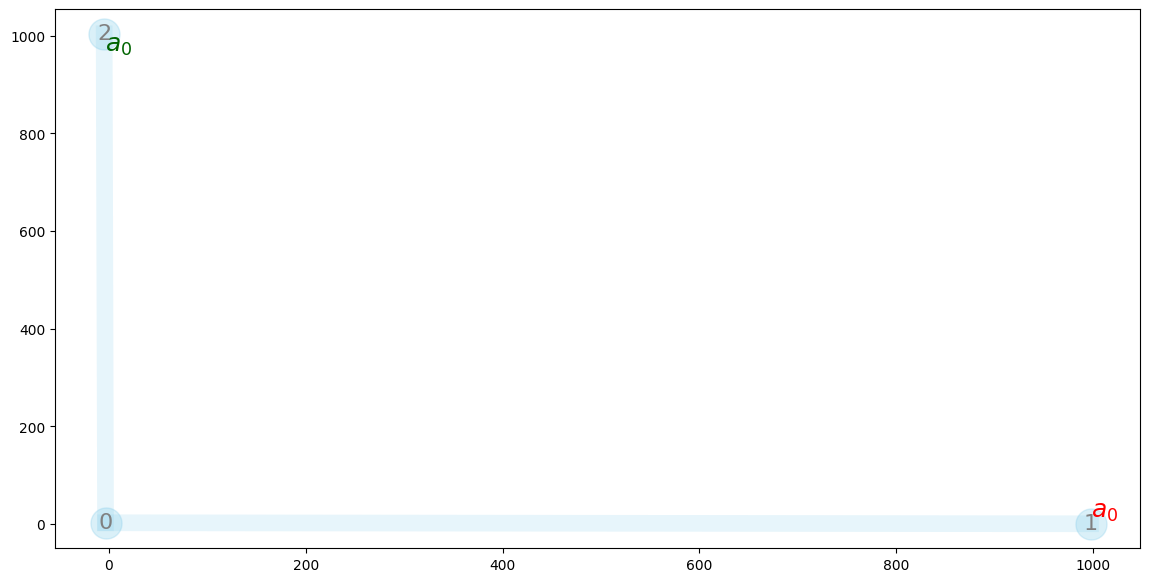

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 3
n_agents = 1
tolArray = np.random.uniform(3.0, 3.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':5
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=12, 
    offset_energy=1,
    selfHop=0,
    printFlag=True)

# compute conflict cost
beta0=1e-8
gamma_t = 5
gamma_c = 7.5
coeff_t = 50
coeff_c = 5.0

# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(14,7), routes=[], agent_colors=agent_colors, showEdgeLength=False)

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [3]:
# agent_0 = mars.agents[0]
# sched0_init = mars.sched_mat[0,:]
# lb0 = np.zeros(sched0_init.shape)
# ub0 = 100 * np.ones(lb0.shape)
# bounds = Bounds(lb0, ub0)
# speed = 50

In [4]:
# beta_min = 1e-5
# beta_max = 1e3
# beta_grow = 3
# beta = beta_min
# beta_arr = []
# while beta <= beta_max:
#     beta_arr.append(beta)
#     beta = beta * beta_grow

In [5]:
# for i, b in enumerate(beta_arr):
#     res = minimize(
#         agent_0.getFreeEnergy_s_v1,
#         sched0_init,
#         args = (mars.dist_mat, b),
#         method='slsqp',
#         options={'disp':0},
#         bounds=bounds
#     )
#     sched0_init = res.x

#     print(f'beta:{b:.4e}\tfreeEnergy:{res.fun:.4f}')



In [6]:
# Pb = agent_0.getPathAssociations_v1(sched0_init, mars.dist_mat, beta=1e8)
# agent_0.calc_route_and_schedule(sched0_init, mars.dist_mat, Pb)
# r = agent_0.route
# s = agent_0.fin_sched
# print(f'agent {agent_0}\n route: {r} \t schedule : {np.round(s,2)}')

### Test the optimization for all the agents together

In [7]:
# # annealing
# sched_vec0 = mars.sched_mat.flatten()

# lb = np.ones(shape=sched_vec0.shape)*mars.t_start_min
# ub = np.ones(shape=sched_vec0.shape)*100.0
# print(f'agent start nodes {mars.agents[0].s}')
# print(f'init schedule vec {sched_vec0}')
# print(f'ub {ub}')
# print(f'lb {lb}')

# sched_bounds = [lb,ub]
# beta_lims = [1e-6,1]
# beta_grow = 1.5
# # opts = {'gtol':1e-4, 'verbose':0, 'maxiter':200}
# opts = {'disp':0}
# C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing_v1(beta_lims=beta_lims,
#                                             beta_grow=beta_grow,
#                                             sched_vec0=sched_vec0,
#                                             init_sched_bounds=sched_bounds,
#                                             optimize_opt=opts,
#                                             allowPrintAnneal=True,
#                                             allowPrintOptimize=False)

# # C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing(beta_lims=beta_lims,
# #                                             beta_grow=beta_grow,
# #                                             sched_vec0=sched_vec0,
# #                                             init_sched_bounds=sched_bounds,
# #                                             optimize_opt=opts,
# #                                             allowPrintAnneal=True,
# #                                             allowPrintOptimize=False)



In [8]:
# importlib.reload(createEnv)
# importlib.reload(flpoAgent)
# print('\nOptimization Results')
# print(f'initial schedule:{sched_vec0}')
# print(f'final schedule:\n{mars.sched_mat}')
# print(f'processing time:\n{mars.process_T}')
# print(f'cost:{C_arr[-1]}')

# agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
# createEnv.plotNetwork(mars=mars, figuresize=(12,8), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False, plotPaths=True)
# # createEnv.plot_vehicle_routes(agent_routes, agent_schedules, mars.process_T, agent_colors)
# # createEnv.plot_waypoint_schedules(filter_wp_beta_data[-1], mars.sched_mat)
# createEnv.plot_waypoint_agent_schedules(
#     agent_routes, agent_schedules, mars.sched_mat, 
#     filter_wp_beta_data[-1], mars.process_T, agent_colors,
#     figuresize=(12,12))
# plt.figure(figsize=(8,4))
# plt.plot(np.log(beta_arr)/np.log(10), conflict_C_arr.sum(axis=1), marker='o', linewidth=2, color='red')
# plt.xlabel(rf'$\log\beta$', fontsize=14)
# plt.ylabel(rf'Cost', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.grid()
# plt.show()
# # agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



### Write a code to solve MARS using CBF-CLF based appraoch

In [16]:
beta_min = 1e-3
beta_max = 1e-3
beta_grow = 1.5
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow


T0 = np.ones((mars.n_agents, mars.n_waypoints))
for i in range(mars.n_agents):
    if i > 0:
        T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0,5, mars.tolArray.shape)
V0 = mars.speed_vec


optimizer = {
    'name':'cbf_clf',
    'dt_init':0.01,
    'dt_min':1e-4,
    'dt_max':0.1,
    'Tf':20,
    'gamma':1,
    'alpha':10,
    'p':1,
    'stop_tol':0.0001,
    'stop_tol_weight':np.array([1, 1, 1]),
    'verbose':2
}



In [17]:
T0, mars.speed_lim_mat, V0, mars.dist_mat

(array([[1., 1., 1.]]),
 array([[ 0.27068187, 68.0060909 ]]),
 array([34.13838638]),
 array([[1.00000000e+08, 1.00109365e+03, 1.00178795e+03],
        [1.00109365e+03, 1.00000000e+08, 1.00000000e+08],
        [1.00178795e+03, 1.00000000e+08, 1.00000000e+08]]))

In [18]:
mars.active_waypoints = []
mars.get_CBF_control(T0, V0, beta=1e5, gamma=1, alpha=2, p=1)

(array([[ 3.06337336e-03,  4.41701337e+00, -2.00000000e+00]]),
 array([15.18723217]),
 3443.109046784349,
 -3443.03373429511,
 array([0.07531249]))

In [19]:
2 * (1001.8)**2/34.14**2 + 2 * (1001.1)**2/34.14**2

3441.8469351019903

In [20]:
-4 * (1001.8)**2/34.14**3 - 4 * (1001.1)**2/34.14**3

-201.63133773298128

In [21]:

active_waypoints = [] #range(mars.n_waypoints) 
T, V, F, Pb_a = mars.anneal(
    beta_arr, 
    T0, 
    V0, 
    active_waypoints=active_waypoints, 
    optimizer=optimizer, 
    annealPrint=True)



	t:0.000e+00	Fdot:-4104.7527	F:4104.8342	dt:1.0000e-02	delta:0.0815	tol:1.382e+03
speed: [34.13838638]
	t:1.000e-02	Fdot:-4063.9826	F:4064.0655	dt:1.0000e-01	delta:0.0830	tol:1.492e+02
speed: [34.30789199]
	t:1.100e-01	Fdot:-3683.6098	F:3683.7092	dt:1.0000e-01	delta:0.0995	tol:2.498e+02
speed: [36.00738916]
	t:2.100e-01	Fdot:-3338.4750	F:3338.6014	dt:7.6331e-02	delta:0.1264	tol:2.001e+02
speed: [37.77403213]
	t:2.863e-01	Fdot:-3096.6047	F:3096.7492	dt:1.0000e-01	delta:0.1445	tol:1.841e+02
speed: [39.26325791]
	t:3.863e-01	Fdot:-2806.9298	F:2807.1009	dt:1.0000e-01	delta:0.1712	tol:1.904e+02
speed: [41.26229488]
	t:4.863e-01	Fdot:-2543.9885	F:2544.1902	dt:1.0000e-01	delta:0.2016	tol:1.727e+02
speed: [43.3201417]
	t:5.863e-01	Fdot:-2305.4032	F:2305.6397	dt:1.0000e-01	delta:0.2365	tol:1.567e+02
speed: [45.43306389]
	t:6.863e-01	Fdot:-2088.9962	F:2089.2726	dt:1.0000e-01	delta:0.2764	tol:1.421e+02
speed: [47.59826299]
	t:7.863e-01	Fdot:-1892.7716	F:1893.0940	dt:1.0000e-01	delta:0.3223	tol:1.

In [23]:
mars.sched_mat

array([[9.73209875e+00, 2.44657132e+01, 2.77707218e-04]])

In [22]:

mars.sched_mat = T
# print(T)
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)



route v0: [2, 0, 1], schedule: [ 0.    9.73 24.47]


In [19]:

T1 = T #np.array([[31.84, 58.85, 0.0],[28.84, 0.0, 55.38]])
V1 = V


In [20]:

mars.transportCost_v1(T1, V1,  beta=beta_arr[-1])
np.sum(mars.agent_weights * mars.C_agents)


906.869669598642

In [21]:


mars.sched_mat = T1
print(T1)
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)



[[1.02939022e+01 2.55465248e+01 3.84584449e-03]]
route v0: [2, 0, 1], schedule: [ 0.   10.29 25.55]


In [27]:
D = mars.dist_mat

In [30]:
D[0,1]/V1[0]

15.252605702406631

In [24]:
V1

array([65.63427044])

In [22]:


# reach_mat = mars.calc_agent_reach_mat_v1(mars.sched_mat, beta_arr[-1])
# filter_wp = np.ones(shape=reach_mat.shape)
# filter_wp[reach_mat <= 1.0e-10] = 0.0
# createEnv.plot_waypoint_agent_schedules(agent_routes, agent_schedules, mars.sched_mat, filter_wp, mars.process_T, agent_colors, figuresize=(16,18))



TypeError: calc_agent_reach_mat_v1() missing 1 required positional argument: 'beta'

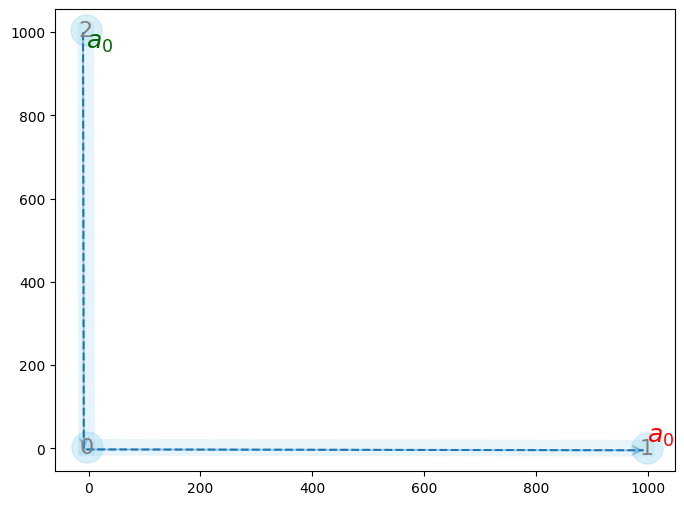

In [23]:
# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(8,6), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False)


In [5]:
import cvxpy as cp
import numpy as np

l1 = 1000
l2 = 1000
Vmin = 0.1
Vmax = 200

def F_Fgrad0(t1, t2, t3):
    V = 50
    cost = (l2/V)**2 + (t3 - t2 - l2/V)**2 + (l1/V)**2 + (t2 - t1 - l1/V)**2 + t1**2
    grad = np.array([
        2*(t1 - t2 + l1/V) + 2*t1,
        2*(t2 - t1 - l1/V) + 2*(t2 - t3 + l2/V),
        2*(t3 - t2 - l2/V)
    ])
    return cost, grad

def F_Fgrad1(V, t1, t2, t3):
    cost = (l2/V)**2 + (t3 - t2 - l2/V)**2 + (l1/V)**2 + (t2 - t1 - l1/V)**2 + t1**2
    grad = np.array([
        2*(t1 - t2 + l1/V) + 2*t1,
        2*(t2 - t1 - l1/V) + 2*(t2 - t3 + l2/V),
        2*(t3 - t2 - l2/V),
        2*l2/V**2 * (t2 - t1 - 2*l2/V) + 2*l1/V**2 * (t3 - t2 - 2*l1/V)
    ])
    return cost, grad

def H_Hgrad(V):
    H = (Vmax - V)*(V - Vmin)
    grad_H = Vmax + Vmin - 2*V
    return H, grad_H

In [6]:
U1 = cp.Variable(1)
U2 = cp.Variable(1)
U3 = cp.Variable(1)
U4 = cp.Variable(1)
delta = cp.Variable(1)
V = 10
t1, t2, t3 = np.random.uniform(0,1000, 3)
gamma = 1
alpha = 1
iters = 3000
step_size = 0.01

for i in range(iters):
    objective = cp.Minimize(U1**2 + U2**2 + U3**2 + U4**2 + delta**2)

    # F, Fgrad = F_Fgrad0(dt)
    # Fdot = cp.multiply(Fgrad, U1)

    F, Fgrad = F_Fgrad1(V, t1, t2, t3)
    Fdot = cp.multiply(Fgrad[0], U1) + cp.multiply(Fgrad[1], U2) + cp.multiply(Fgrad[2], U3) + cp.multiply(Fgrad[3], U4)

    H, Hgrad = H_Hgrad(V)
    Hdot = cp.multiply(Hgrad, U4)

    constraints = [
        Fdot <= -gamma * F + delta,
        Hdot >= -alpha * H,
        U1 >= -alpha * t1
    ]

    problem = cp.Problem(objective, constraints)
    solver_options = {
        'max_iter': 50000,         # Increase max iterations to 20000
        'eps_abs': 1e-4,           # Adjust absolute tolerance
        'eps_rel': 1e-4,           # Adjust relative tolerance
        'eps_prim_inf': 1e-3,      # Adjust primal infeasibility tolerance
        'eps_dual_inf': 1e-3,      # Adjust dual infeasibility tolerance
        'verbose': False           # Enable verbose output to track solver progress
    }
    result = problem.solve(solver = 'OSQP', **solver_options)

    t1 = t1 + step_size * U1.value
    t2 = t2 + step_size * U2.value
    t3 = t3 + step_size * U3.value
    V = V + step_size * U4.value

    print(f't1:{t1[0]:.3f}\tt2:{t2[0]:.3f}\tt3:{t3[0]:.3f}\tV:{V[0]:.3f}')
    # print(f'iter:{i}\tt1:{t1[0]:.3f}\tt2:{t2[0]:.3f}\tt3:{t3[0]:.3f}\tV:{V[0]:.3f}\tU1:{U1.value[0]:.3f}\tU2:{U2.value[0]:.3f}\tU3:{U3.value:.3f}')


t1:433.086	t2:849.839	t3:757.118	V:11.474
t1:432.559	t2:847.244	t3:758.034	V:12.425
t1:431.987	t2:844.315	t3:759.020	V:12.293
t1:431.391	t2:841.378	t3:760.004	V:12.229
t1:430.773	t2:838.437	t3:760.980	V:12.168
t1:430.134	t2:835.490	t3:761.950	V:12.107
t1:429.472	t2:832.537	t3:762.913	V:12.047
t1:428.787	t2:829.578	t3:763.868	V:11.986
t1:428.079	t2:826.614	t3:764.816	V:11.926
t1:427.347	t2:823.644	t3:765.756	V:11.865
t1:426.591	t2:820.667	t3:766.687	V:11.805
t1:425.811	t2:817.685	t3:767.610	V:11.745
t1:425.006	t2:814.696	t3:768.525	V:11.685
t1:424.175	t2:811.701	t3:769.430	V:11.625
t1:423.319	t2:808.700	t3:770.326	V:11.565
t1:422.436	t2:805.693	t3:771.212	V:11.505
t1:421.526	t2:802.679	t3:772.088	V:11.445
t1:420.589	t2:799.658	t3:772.953	V:11.385
t1:419.624	t2:796.632	t3:773.808	V:11.326
t1:418.631	t2:793.598	t3:774.651	V:11.266
t1:417.609	t2:790.559	t3:775.482	V:11.207
t1:416.558	t2:787.513	t3:776.300	V:11.148
t1:415.477	t2:784.461	t3:777.106	V:11.088
t1:414.366	t2:781.402	t3:777.899	V